# <center>Data acquisition and reproducible research</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: fundamentals of research in python</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Distinguish the three acquisition patterns, **API**, **bulk download**, **scraping**, and know which to use.

* Read an HTTP response: status code, headers, body; and parse JSON into a `DataFrame`.

* **Archive every response and verify it by hash.** A result that depends on a live request is not reproducible until the response is stored, and this lecture builds the mechanism that makes it so: together with the check that detects when a source has changed underneath you.

* Query a keyless REST API (World Bank), and handle a keyed one (FRED) **without ever committing the key**.

* Parse HTML with `pd.read_html` and `BeautifulSoup`, and know why scraping is the last resort.

* Separate the three permissions, may I obtain, may I use, may I redistribute, and act on the etiquette that keeps you, and your institution, unblocked.

* **Assemble reproducibility as seven concrete practices**, environment, version control, seeds, incidental seeds, data manifest, tests, run record, and know the difference between *conclusions-stable* reproduction and byte-identity.

* Understand what a **proof assistant** adds: the same discipline applied to the mathematics itself, and why a machine-checked theorem is a different object from a passing test grid.

**On the duality lens.** This lecture has none, and it is not applicable: there is no optimization here and therefore no multiplier. What it contributes instead is *provenance*: the discipline that makes the data in `fd06` §15 something a reader can obtain and check for themselves, and that makes any number in this series something a reader can regenerate.

### References

**[R]** *Requests: HTTP for Humans*. https://requests.readthedocs.io/.

**[BS]** *Beautiful Soup Documentation*. https://www.crummy.com/software/BeautifulSoup/bs4/doc/.

**[WB]** World Bank Open Data API. https://datahelpdesk.worldbank.org/knowledgebase/topics/125589.

**[FRED]** Federal Reserve Bank of St. Louis, FRED API. https://fred.stlouisfed.org/docs/api/fred/.

**[EU-DB]** Directive 96/9/EC on the legal protection of databases (the *sui generis* database right).

**[Wi]** Wilson, G. et al. (2017). "Good Enough Practices in Scientific Computing." *PLOS Computational Biology* 13(6): on raw data as a read-only archive.

## 1. Web data and reproducibility

Three patterns cover almost all acquisition.

* **API**: an HTTP endpoint returning structured data, usually JSON. Documented parameters, stable schema, rate-limited. *Use this whenever it exists.* Nearly all are **REST** APIs: each dataset is a URL, you `GET` it with parameters in the query string, each request stands alone, and the response describes the current state of the resource.
* **Bulk download**: a file at a stable URL. Easiest of all: `pd.read_csv("https://...")` and you are done.
* **Scraping**: parsing a human-readable HTML page. Fragile, often against the terms of service. *Last resort.*

But every one of them introduces a problem the rest of this series has been careful to avoid. Everything computed so far is a deterministic function of things in the notebook: `fd08`'s Monte Carlo is fixed by its seed, `fd06`'s marriage data sit in a file. **A live request is not like that.** The World Bank revises its national accounts; Wikipedia is edited continuously; Yahoo restructures its endpoints. Run the same notebook next year and you may get different numbers, with nothing in the code changed and nothing to tell you what happened.

That is not a minor inconvenience. It means a result cannot be checked. So this lecture's organizing rule is:

> **Archive the raw response, record its hash, and compute from the archive.** The live call happens once, deliberately, and is recorded; every later run reads the archive and verifies it.

§3 builds that mechanism, and everything after uses it.

## 2. A brief overview of HTTP and JSON

Every request is a **method** plus a **URL** plus optional headers and body. The response carries a **status code**, 200 success, 404 not found, 403 forbidden, 429 rate-limited, 500 server error, some headers, and a body. *The status code is the first thing to check*, and `raise_for_status()` is the one-line way to check it.

For data work you will use `GET` almost exclusively. **JSON** is what most APIs return: nested key–value objects and arrays, which map onto Python dicts and lists, and which `requests` parses with `.json()`.

In [1]:
import json
import gzip
import hashlib
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

payload = """
{"indicator": {"id": "NY.GDP.PCAP.KD", "value": "GDP per capita"},
 "observations": [{"country": "FRA", "date": "2020", "value": 38515.6},
                  {"country": "FRA", "date": "2021", "value": 41065.4}]}
"""

parsed = json.loads(payload)
print(f"top-level keys : {list(parsed)}")
print(f"indicator name : {parsed['indicator']['value']}")
print(f"observations   : {len(parsed['observations'])} records\n")

print(pd.DataFrame(parsed["observations"]))

top-level keys : ['indicator', 'observations']
indicator name : GDP per capita
observations   : 2 records

  country  date    value
0     FRA  2020  38515.6
1     FRA  2021  41065.4


## 3. Archive and verify

Here is the mechanism the rest of the lecture runs on. It is about thirty lines and it is the single most useful thing in this notebook.

The design has three parts.

* **A cache directory** holding the *raw bytes* of every response, gzipped. Raw, not parsed: your parsing may turn out to be wrong, and you cannot re-parse what you did not keep.
* **A manifest** recording, for each entry, the URL, the UTC time of the fetch, the size, and the **SHA-256** of the payload.
* **A switch.** `LIVE = False` reads the archive; `LIVE = True` re-fetches and *compares the new hash against the recorded one*, which is what turns "the data changed" from an invisible event into a reported one.

The cache belongs in version control, next to the code: it is the `data/` of the research compendium of `fd05` §10. The `generated/` folder of `fd06` held disposable byproducts; this is the opposite, an input you must not lose.

In [2]:
CACHE = Path("data_cache")
MANIFEST = json.loads((CACHE / "manifest.json").read_text(encoding="utf-8"))

LIVE = False          # set True to re-fetch from source and compare against the manifest

USER_AGENT = {"User-Agent": "math-econ-code course notebook (teaching example)"}

def sha256(raw: bytes) -> str:
    return hashlib.sha256(raw).hexdigest()

def load_raw(name):
    """Return the archived bytes for `name`, verified against the manifest."""
    entry = MANIFEST[name]
    raw = gzip.open(CACHE / entry["stored_as"], "rb").read()
    digest = sha256(raw)
    if digest != entry["sha256"]:
        raise ValueError(f"{name}: archive is corrupt "
                         f"(sha256 {digest[:12]} != recorded {entry['sha256'][:12]})")
    return raw

def fetch_raw(name):
    """Re-fetch from source and report whether the payload still matches."""
    entry = MANIFEST[name]
    response = requests.get(entry["url"], headers=USER_AGENT, timeout=30)
    response.raise_for_status()
    digest = sha256(response.content)
    if digest == entry["sha256"]:
        print(f"{name}: source unchanged since {entry['fetched_at']}")
    else:
        print(f"{name}: SOURCE HAS CHANGED since {entry['fetched_at']}\n"
              f"   archived {entry['bytes']:,} bytes, now {len(response.content):,}")
    return response.content

def get(name):
    return fetch_raw(name) if LIVE else load_raw(name)

print(f"{'entry':<34}{'bytes':>10}{'fetched (UTC)':>22}")
print("-" * 66)
for name, entry in MANIFEST.items():
    print(f"{name:<34}{entry['bytes']:>10,}{entry['fetched_at']:>22}")
print("-" * 66)
print(f"LIVE = {LIVE}: reading from the archive")

entry                                  bytes         fetched (UTC)
------------------------------------------------------------------
worldbank_gdp_per_capita.json         26,071  2026-08-29T12:49:08Z
wikipedia_gdp_per_capita.html        578,990  2026-08-29T12:49:08Z
prices_aapl_msft.csv                  24,329  2026-08-29T12:49:09Z
------------------------------------------------------------------
LIVE = False: reading from the archive


In [3]:
# every archived payload verifies against its recorded hash
for name in MANIFEST:
    raw = load_raw(name)
    print(f"{name:<34} {len(raw):>9,} bytes   sha256 {sha256(raw)[:16]}...  OK")

# and the check is not vacuous: corrupt one byte and it fires
corrupted = bytearray(load_raw("worldbank_gdp_per_capita.json"))
corrupted[100] = (corrupted[100] + 1) % 256
print(f"\nflip a single byte -> sha256 {sha256(bytes(corrupted))[:16]}...")
print(f"matches the manifest: "
      f"{sha256(bytes(corrupted)) == MANIFEST['worldbank_gdp_per_capita.json']['sha256']}")
print("\ncheck passed: the archive is intact, and the verification detects a one-byte change.")

worldbank_gdp_per_capita.json         26,071 bytes   sha256 38f426025a0a8203...  OK
wikipedia_gdp_per_capita.html        578,990 bytes   sha256 bd762211e5485453...  OK
prices_aapl_msft.csv                  24,329 bytes   sha256 bc2013cf1f6bca71...  OK

flip a single byte -> sha256 fbd3dd2f373c1a91...
matches the manifest: False

check passed: the archive is intact, and the verification detects a one-byte change.


The corrupted-byte demonstration is the point. A hash that never fails is not evidence of anything; showing that it *does* fail on a single flipped byte is what makes the passing check meaningful: the same argument as `fd11`'s post-selection Monte Carlo, where a coverage check is informative only because we also saw it break.

**What this buys you, and what it does not.** It buys reproducibility of everything downstream: the numbers in this notebook are a deterministic function of files you can inspect, and anyone with the repository gets the same results in five years, offline. It does not buy *currency*: the archive is a snapshot, and a snapshot goes stale. Deciding when to re-fetch is a research judgement; `LIVE = True` is how you exercise it, and the hash comparison is what tells you whether anything moved.

## 4. A keyless API: the World Bank

The World Bank's Open Data API needs no key. Its URLs have the shape

```
https://api.worldbank.org/v2/country/{codes}/indicator/{indicator}?format=json&date=2000:2022
```

with countries separated by semicolons. The indicator here, `NY.GDP.PCAP.KD`, is GDP per capita in constant 2015 US dollars.

The response is a **two-element array**: metadata first, then the records. That shape is common and worth checking rather than assuming: an API that returns an error still returns valid JSON, just with a different structure.

In [4]:
raw = get("worldbank_gdp_per_capita.json")
meta, records = json.loads(raw)

print(f"metadata: {meta}")
print(f"records : {len(records)}   (expected {meta['total']})")
assert len(records) == meta["total"], "the API paginated; we only have page 1"
print(f"\none record:\n{json.dumps(records[0], indent=2)[:280]}")

metadata: {'page': 1, 'pages': 1, 'per_page': 500, 'total': 115, 'sourceid': '2', 'lastupdated': '2026-07-13'}
records : 115   (expected 115)

one record:
{
  "indicator": {
    "id": "NY.GDP.PCAP.KD",
    "value": "GDP per capita (constant 2015 US$)"
  },
  "country": {
    "id": "DE",
    "value": "Germany"
  },
  "countryiso3code": "DEU",
  "date": "2022",
  "value": 44817.1316331389,
  "unit": "",
  "obs_status": "",
  "decimal


Note the assertion. The metadata reports `pages: 1`, so a single request captured everything, but had the query been larger, the API would have paginated silently and we would have analysed the first 50 records of several hundred. **Checking the returned count against the reported total is the cheapest guard against the most common API bug**, and it is the same discipline as checking a merge's row count in `fd06` §12.

panel (23, 5): 2000-2022, 5 countries
country   France  Germany    Japan  United Kingdom  United States
year                                                             
2020     35709.0  42373.0  35363.0         42985.0        59534.0
2021     38031.0  44011.0  36793.0         46492.0        63097.0
2022     38868.0  44817.0  37448.0         48410.0        64322.0

missing values: 0


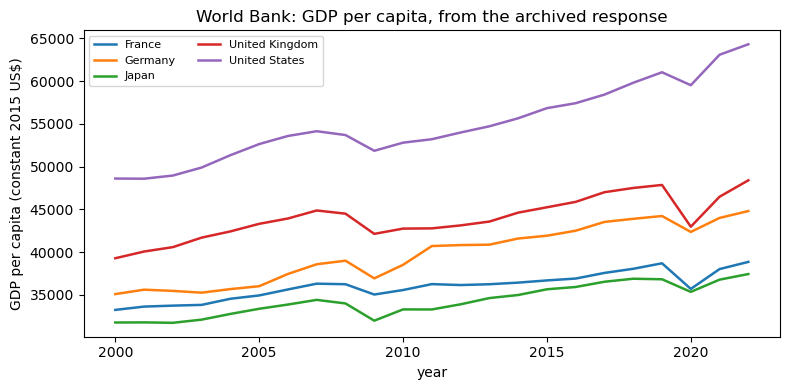

In [5]:
wb = pd.DataFrame([{"country": r["country"]["value"],
                    "iso3": r["countryiso3code"],
                    "year": int(r["date"]),
                    "gdp_pc": r["value"]} for r in records])

panel = wb.pivot(index="year", columns="country", values="gdp_pc").sort_index()
print(f"panel {panel.shape}: {panel.index.min()}-{panel.index.max()}, "
      f"{panel.shape[1]} countries")
print(panel.tail(3).round(0).to_string())
print(f"\nmissing values: {int(panel.isna().sum().sum())}")

fig, ax = plt.subplots(figsize=(8, 4))
panel.plot(ax=ax, lw=1.8)
ax.set_ylabel("GDP per capita (constant 2015 US$)")
ax.set_xlabel("year"); ax.set_title("World Bank: GDP per capita, from the archived response")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 5. APIs with keys: FRED and credential management

Many APIs require a key for rate-limiting and attribution. FRED is the canonical example.

1. **Get one.** Free and instant: https://fred.stlouisfed.org/docs/api/api_key.html.
2. **Never put it in a code cell.** Read it from the environment with `os.environ.get("FRED_API_KEY")`. Set it at the OS level (`setx FRED_API_KEY yourkey` on Windows, `export ...` in your shell profile elsewhere), or keep it in a `.env` file: remembering that Python does *not* read `.env` by itself: `pip install python-dotenv`, then `from dotenv import load_dotenv; load_dotenv()` before reading the environment. Either way, `.env` goes in `.gitignore`.
3. **Treat a leaked key as compromised.** `fd05` §5 made the point about secrets in Git history: removing it from the current files does not remove it from the history, and the history is what you push.

The request pattern, which we document rather than run, since running it would require a key:

```python
import os, requests

key = os.environ.get("FRED_API_KEY")
if key is None:
    raise RuntimeError("set FRED_API_KEY in your environment first")

response = requests.get(
    "https://api.stlouisfed.org/fred/series/observations",
    params={"series_id": "GDPC1", "api_key": key, "file_type": "json"},
    headers=USER_AGENT, timeout=30)
response.raise_for_status()
observations = response.json()["observations"]      # list of dicts, values as STRINGS
```

Two details that bite. FRED returns numeric values as **strings**, with `"."` for missing, so you must convert explicitly: `pd.to_numeric(..., errors="coerce")` is the idiom. And for a single series without a key there is a plain CSV endpoint, `https://fred.stlouisfed.org/graph/fredgraph.csv?id=GDPC1`, which is a *bulk download* in §1's taxonomy and readable directly with `pd.read_csv`.

The cell below shows the parsing on a small literal payload, so the mechanics are visible without a key.

In [6]:
fred_like = {"observations": [
    {"realtime_start": "2026-01-01", "date": "2024-01-01", "value": "22679.255"},
    {"realtime_start": "2026-01-01", "date": "2024-04-01", "value": "."},
    {"realtime_start": "2026-01-01", "date": "2024-07-01", "value": "23400.994"}]}

obs = pd.DataFrame(fred_like["observations"])[["date", "value"]]
print("as returned -- note the dtypes:")
print(obs.dtypes.to_string())

obs["date"] = pd.to_datetime(obs["date"])
obs["value"] = pd.to_numeric(obs["value"], errors="coerce")   # '.' becomes NaN
print(f"\nafter conversion:\n{obs.to_string(index=False)}")
print(f"\ndtypes now: {obs.dtypes.to_dict()}")
assert obs['value'].isna().sum() == 1
print("check passed: the '.' placeholder became a proper NaN, not the string '.'.")

as returned -- note the dtypes:
date     object
value    object

after conversion:
      date     value
2024-01-01 22679.255
2024-04-01       NaN
2024-07-01 23400.994

dtypes now: {'date': dtype('<M8[ns]'), 'value': dtype('float64')}
check passed: the '.' placeholder became a proper NaN, not the string '.'.


## 6. Library wrappers: `yfinance`

For market data, `yfinance` wraps Yahoo Finance. It scrapes under the hood, Yahoo has no official public API, so expect breakage when Yahoo redesigns, and **pin the version** in your environment file. The interface:

```python
import yfinance as yf
prices = yf.download(["AAPL", "MSFT"], start="2023-01-01", end="2024-12-31",
                     auto_adjust=True, progress=False)["Close"]
```

That call produced the archived CSV we read below. `auto_adjust=True` matters: it adjusts for splits and dividends, and without it a stock split appears as a 50% one-day crash.

In [7]:
import io

prices = pd.read_csv(io.BytesIO(get("prices_aapl_msft.csv")),
                     index_col=0, parse_dates=True)
returns = np.log(prices).diff().dropna()

print(f"{prices.shape[0]} trading days, {prices.index.min().date()} to {prices.index.max().date()}")
print(f"\n{'ticker':<8}{'ann. return':>13}{'ann. vol':>11}{'Sharpe':>9}")
print("-" * 41)
for ticker in prices.columns:
    mu = 252 * returns[ticker].mean()
    sd = np.sqrt(252) * returns[ticker].std()
    print(f"{ticker:<8}{mu:>12.1%}{sd:>11.1%}{mu / sd:>9.2f}")
print("-" * 41)
print(f"correlation of daily log returns: {returns.corr().iloc[0, 1]:.3f}")

# a sanity check that costs nothing: prices must be positive and dates ordered
assert (prices > 0).all().all() and prices.index.is_monotonic_increasing
print("\ncheck passed: positive prices, dates in order.")

501 trading days, 2023-01-03 to 2024-12-30

ticker    ann. return   ann. vol   Sharpe
-----------------------------------------
AAPL           35.9%      21.3%     1.68
MSFT           29.7%      22.7%     1.31
-----------------------------------------
correlation of daily log returns: 0.506

check passed: positive prices, dates in order.


Two remarks. The annualization factors $252$ and $\sqrt{252}$ are the trading-day conventions, and the $\sqrt{\cdot}$ on volatility is the $N^{-1/2}$ scaling of `fd08` §17 in another costume: variance adds over independent periods, so standard deviation grows with the square root of horizon.

And the checks on the last lines are the kind worth writing for *every* acquired dataset: an assertion that the data satisfy something you know must be true. Negative prices or out-of-order dates would indicate a parsing failure, and catching that here is far cheaper than discovering it in a regression three weeks later.

## 7. HTML scraping

When there is no API and no bulk file, you parse the page. Two tools:

* **`pd.read_html`** finds `<table>` elements and returns a list of DataFrames. If the data are already in a table, this is the whole job.
* **`BeautifulSoup`** walks the document tree, for anything that is not a clean table.

Both are demonstrated on the archived Wikipedia page. Note the order: we parse from the *archive*, not from the live page: a scraper that hits the network every run is a result that cannot be reproduced.

In [8]:
html = get("wikipedia_gdp_per_capita.html").decode("utf-8")
print(f"archived page: {len(html):,} characters")

tables = pd.read_html(io.StringIO(html))       # StringIO: literal HTML is deprecated
print(f"read_html found {len(tables)} tables")
for i, t in enumerate(tables[:3]):
    print(f"  table {i}: {t.shape}  {list(t.columns)[:2]}")

gdp_table = tables[1].copy()          # .copy(): renaming below must not touch tables[1]
gdp_table.columns = ["country", "imf", "world_bank", "un"]
print(f"\nthe country table as parsed: {gdp_table.shape}")
print(gdp_table.head(3).to_string(index=False))
print("   ... all NaN. The page contains empty <tr> rows that read_html faithfully kept.")

blank = gdp_table.isna().all(axis=1)
gdp_table = gdp_table[~blank].reset_index(drop=True)
print(f"\ndropped {int(blank.sum())} all-empty rows -> {gdp_table.shape}")
print(gdp_table.head(4).to_string(index=False))
assert not gdp_table.isna().all(axis=1).any() and len(gdp_table) > 200

archived page: 574,625 characters
read_html found 6 tables
  table 0: (1, 2)  [0, 1]
  table 1: (228, 4)  ['Country/Territory', 'IMF (2026)[a][5]']
  table 2: (9, 2)  ['vteLists of countries by GDP rankings', 'vteLists of countries by GDP rankings.1']

the country table as parsed: (228, 4)
country imf world_bank  un
    NaN NaN        NaN NaN
    NaN NaN        NaN NaN
    NaN NaN        NaN NaN
   ... all NaN. The page contains empty <tr> rows that read_html faithfully kept.

dropped 5 all-empty rows -> (223, 4)
      country    imf     world_bank     un
       Monaco   —N/a 288,002 (2024) 288002
Liechtenstein 226809 220,167 (2024) 216392
   Luxembourg 158733         147252 138596
      Bermuda   —N/a 142,250 (2024) 136766


In [9]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html, "lxml")
print(f"page title : {soup.title.string.strip()[:60]}")

# what read_html does for you, done by hand -- and note the guard
table_tag = soup.find("table", {"class": "wikitable"})
rows = table_tag.find_all("tr")
with_cells = [tr for tr in rows if tr.find_all(["td", "th"])]

print(f"\n<tr> elements: {len(rows)}, of which {len(with_cells)} contain any cell")
print(f"the {len(rows) - len(with_cells)} empty ones are why the naive parse above was blank.\n")

for tr in with_cells[1:4]:                     # [0] is the header row
    cells = [td.get_text(strip=True) for td in tr.find_all(["td", "th"])]
    print(f"   {cells[:4]}")

print(f"\nlinks on the page: {len(soup.find_all('a')):,}")

page title : List of countries by GDP (nominal) per capita - Wikipedia



<tr> elements: 229, of which 224 contain any cell
the 5 empty ones are why the naive parse above was blank.

   ['Monaco', '—N/a', '288,002 (2024)', '288,002']
   ['Liechtenstein', '226,809', '220,167 (2024)', '216,392']
   ['Luxembourg', '158,733', '147,252', '138,596']

links on the page: 795


Note the `.copy()` in the previous cell. `tables[1]` and `gdp_table` would otherwise be the same object, and renaming the columns of one would rename them on the other: the aliasing of `fd02` §7, in its pandas form. Exercise 2 compares a fresh parse against `tables[1]`, and without the copy that comparison would fail for a reason having nothing to do with the exercise.

| selector | what it finds |
|---|---|
| `soup.find_all("a")` | every link |
| `soup.find("div", {"class": "summary"})` | the first `<div class="summary">` |
| `soup.select(".price-tag > span")` | a CSS selector path |
| `tag.get("href")` | an attribute |
| `tag.parent`, `tag.next_sibling` | tree navigation |

The working method: open the page in a browser, open the inspector, copy the CSS selector of the element you want, paste it into `soup.select(...)`. Most scraping is that loop.

**Look at what just happened, because it is the lecture in miniature.** `read_html` returned a 228-row table whose first five rows are entirely `NaN`: the page contains empty `<tr>` elements, and the parser faithfully reproduced them. A `.head()` shows nothing but `NaN`, and code that computed a mean over that column without looking would have silently used 223 values where it believed it had 228. The BeautifulSoup walk hits the same rocks: iterating `rows[1:4]` lands squarely in the empty block and prints three empty lists.

Neither is a bug in pandas or in Wikipedia. It is what HTML *is*, a layout format, not a data format, and it is why the first thing to do after any scrape is to look at the result and assert something about it. The fix in both cells is the same: select rows by whether they contain data, not by where they sit.

**And note how fragile the rest of it is.** Our parse depends on the table being at index 1 and on its column count. Wikipedia is edited continuously; a contributor adding an infobox above the table would silently shift the index and our code would happily parse the wrong table. That is precisely why the page is archived: the notebook's numbers come from a fixed snapshot, and `LIVE = True` reports that the page has changed rather than quietly analysing something else.

## 8. Responsible acquisition

A request that floods a server, ignores its rules, or impersonates a browser gets your IP blocked, or, from a university network, your institution's whole subnet.

**Five habits.**

1. **Read the terms of service.** Many APIs are free for research and restricted for redistribution. One paragraph, once.
2. **Respect `robots.txt`** at `<site>/robots.txt`. The standard library's `urllib.robotparser` reads it. Even where it does not formally bind you, ignoring it is rude.
3. **Identify yourself** with a `User-Agent` naming the project and a contact: as this notebook does.
4. **Rate-limit, and back off when told to.** Sleep between calls with a margin under the published limit, and on a `429` or a `5xx` retry with *exponential* backoff, one second, then two, then four, rather than hammering a struggling server. Write such a fetcher with `get` and `sleep` **injected as arguments** with sensible defaults: a test can then pass a fake response sequence and a list that records the sleeps, and assert the backoff schedule without a single network call or a single real second spent. That is `fd04` §5's principle, a function whose external dependencies arrive as arguments is testable, applied to the one part of acquisition that is otherwise untestable.
5. **Cache**, which is §3, and which reduces both your bandwidth and theirs. The `requests-cache` package is a drop-in that intercepts `requests.get` transparently; the explicit archive of §3 is preferable for research because it is *inspectable and versioned*.

### Three permissions, not one

Politeness is necessary and not sufficient. Keep three questions separate.

1. **May I obtain the data this way?** Publicly visible is not unrestricted. Do not evade a login, paywall, CAPTCHA or rate limit, and do not use credentials supplied without authority. `robots.txt` states crawling instructions; it is neither a copyright licence nor a statement of the law.
2. **May I use and retain it for this research?** Contractual restrictions, privacy and confidentiality, research-ethics approval, and intellectual property all apply independently. Facts may be unprotected while the *selection and arrangement* of a database is protected; in the EU the *sui generis* database right can restrict extraction of a substantial part of a protected database [EU-DB].
3. **May I redistribute it?** A separate permission again. A licence may allow you to query and analyse while forbidding you to republish the underlying data.

The practical consequence for a replication package is worth stating plainly. When you may not redistribute the data, ship the **code that acquires it**, the **manifest** of §3, URLs, timestamps, hashes, and any derived statistics you are permitted to publish. A reader can then re-acquire the data themselves and verify, by hash, that they obtained what you did. That is the reproducibility standard the archive of §3 was built to meet.

## 9. Worked example: a country panel, and detecting drift

We combine the World Bank series with a second source, and then do the thing this lecture exists for: check whether either source has moved since it was archived.

In [10]:
population = pd.DataFrame({
    "country": ["France", "Germany", "Japan", "United Kingdom", "United States"],
    "population_m": [68.0, 84.4, 124.5, 67.6, 334.9],
    "region": ["Europe", "Europe", "Asia", "Europe", "Americas"],
})

latest = (wb[wb["year"] == wb["year"].max()][["country", "gdp_pc"]]
          .merge(population, on="country", how="left", validate="one_to_one"))
assert latest["population_m"].notna().all(), "a country failed to match"

latest["gdp_total_bn"] = latest["gdp_pc"] * latest["population_m"] / 1000
print(f"year {wb['year'].max()}:\n")
print(latest.sort_values("gdp_pc", ascending=False).round(1).to_string(index=False))

year 2022:

       country  gdp_pc  population_m   region  gdp_total_bn
 United States 64322.2         334.9 Americas       21541.5
United Kingdom 48410.1          67.6   Europe        3272.5
       Germany 44817.1          84.4   Europe        3782.6
        France 38868.3          68.0   Europe        2643.0
         Japan 37448.4         124.5     Asia        4662.3


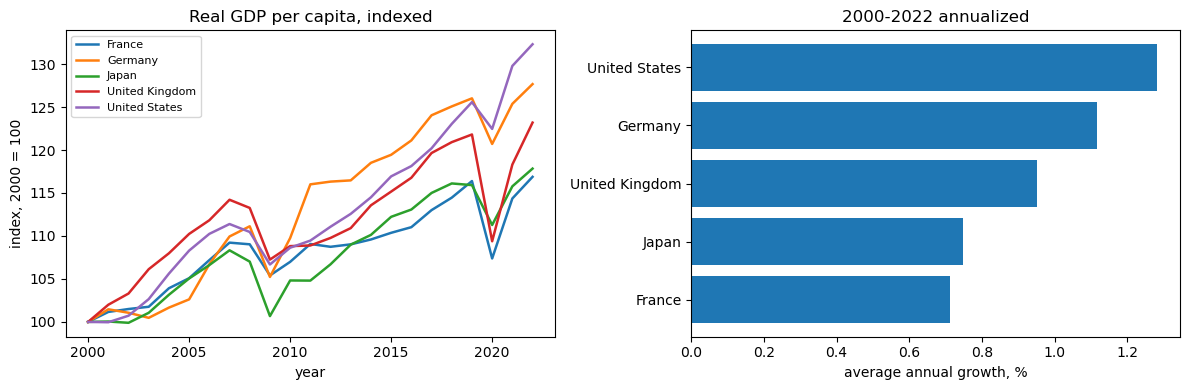

country
United States     1.28
Germany           1.12
United Kingdom    0.95
Japan             0.75
France            0.71


In [11]:
# growth over the sample, from the archived panel
growth = (panel.iloc[-1] / panel.iloc[0]) ** (1 / (panel.index[-1] - panel.index[0])) - 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
normalized = panel / panel.iloc[0] * 100
normalized.plot(ax=axes[0], lw=1.8)
axes[0].set_ylabel(f"index, {panel.index[0]} = 100"); axes[0].set_xlabel("year")
axes[0].set_title("Real GDP per capita, indexed"); axes[0].legend(fontsize=8)

axes[1].barh(growth.sort_values().index, growth.sort_values().values * 100)
axes[1].set_xlabel("average annual growth, %")
axes[1].set_title(f"{panel.index[0]}-{panel.index[-1]} annualized")
plt.tight_layout(); plt.show()

print(growth.sort_values(ascending=False).mul(100).round(2).to_string())

In [12]:
# the drift check. With LIVE = False this reports what WOULD be compared;
# set LIVE = True at the top and re-run to actually query the sources.
print(f"LIVE = {LIVE}\n")
print(f"{'source':<34}{'archived':>12}{'fetched (UTC)':>22}")
print("-" * 68)
for name, entry in MANIFEST.items():
    age_days = (datetime.now(timezone.utc)
                - datetime.strptime(entry["fetched_at"], "%Y-%m-%dT%H:%M:%SZ")
                .replace(tzinfo=timezone.utc)).days
    print(f"{name:<34}{entry['bytes']:>12,}{entry['fetched_at']:>22}   ({age_days}d old)")
print("-" * 68)

if LIVE:
    for name in MANIFEST:
        fetch_raw(name)
else:
    print("archive in use; set LIVE = True to re-fetch and compare hashes.")

LIVE = False

source                                archived         fetched (UTC)
--------------------------------------------------------------------
worldbank_gdp_per_capita.json           26,071  2026-08-29T12:49:08Z   (0d old)
wikipedia_gdp_per_capita.html          578,990  2026-08-29T12:49:08Z   (0d old)
prices_aapl_msft.csv                    24,329  2026-08-29T12:49:09Z   (0d old)
--------------------------------------------------------------------
archive in use; set LIVE = True to re-fetch and compare hashes.


Every number in this notebook is now a deterministic function of three files in `data_cache/`, each verified by hash against a manifest that records where and when it came from. The analysis reproduces offline, today and in five years.

The economics in the figure is the convergence story of `fd03` §9 and `fd09` §10, seen in data rather than in a model. Over 2000–2022 the poorer of these five economies did not systematically grow faster: this is a rich-country sample, all near their steady states, which is exactly the regime in which the Solow model predicts *no* convergence. Testing convergence properly requires the cross-country sample the growth literature uses, and the standard caution applies: conditional convergence is a statement about economies approaching *their own* steady states, not a common one.

## 10. Reproducibility, assembled

This is where the series' debts come due. Across seven lectures we have accumulated the pieces of a reproducibility practice one at a time; here they are as a checklist, with the lecture that argued for each. Two of the seven point *forward*, you have not met a random number generator yet, and that is deliberate: the habit is worth having before the lecture that would otherwise teach you to do without it.

| | practice | argued in |
|---|---|---|
| 1 | **Pin the environment.** `conda env export --from-history > environment.yml`, so a reader recreates the versions you used. | `fd01` §2.2, `fd03` §8; and `fd06`'s `FutureWarning` is the concrete case |
| 2 | **Version-control everything**: code, environment file, README, figure scripts, and the data manifest. | `fd05` |
| 3 | **Seed every generator, and pass it explicitly.** `rng = np.random.default_rng(seed)`, never the legacy global. | `fd08` §16, ahead |
| 4 | **Seed the incidental randomness too**: cross-validation folds, train/test splits, initializations. | `fd11` Ex 4, ahead, where $\lambda_{\min}$ moves with the fold seed |
| 5 | **Archive acquired data and record its hash.** | §3 above |
| 6 | **Test the code**, so "this reproduces the result" is checkable rather than asserted. | `fd04` §5 |
| 7 | **Record the state of the run**, versions, platform, commit, date, in the output itself. | below |

**Reproducible is not the same as non-random**, and it is worth saying plainly: a seeded Monte Carlo gives the same answer every run *by construction* and is no less random in the statistical sense. The seed is bookkeeping, not bias, and without it you cannot distinguish a genuine change in your results from a different draw.

Item 7 is one cell, and it belongs at the top of every research notebook.

In [13]:
import platform
import subprocess
import sys
import time
import importlib.metadata as md

OUT_DIR = Path("generated")          # disposable byproducts, as in fd06
OUT_DIR.mkdir(exist_ok=True)

def git_commit():
    try:
        out = subprocess.run(["git", "rev-parse", "--short", "HEAD"],
                             capture_output=True, text=True, timeout=10)
        return out.stdout.strip() if out.returncode == 0 else "(not a git repository)"
    except (FileNotFoundError, subprocess.TimeoutExpired):
        return "(git unavailable)"

def version_of(dist):
    try:
        return md.version(dist)
    except md.PackageNotFoundError:
        return "not installed"

print("=" * 52)
print("REPRODUCIBILITY HEADER")
print("=" * 52)
print(f"{'run at (UTC)':<16}{time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime())}")
print(f"{'python':<16}{sys.version.split()[0]}")
print(f"{'platform':<16}{platform.system()} {platform.release()} ({platform.machine()})")
for dist in ("numpy", "scipy", "pandas", "matplotlib", "scikit-learn", "numba"):
    print(f"{dist:<16}{version_of(dist)}")
print(f"{'git commit':<16}{git_commit()}")
print("=" * 52)

REPRODUCIBILITY HEADER
run at (UTC)    2026-08-29 16:28:58
python          3.12.3
platform        Windows 11 (ARM64)
numpy           1.26.4
scipy           1.16.0
pandas          2.2.3
matplotlib      3.9.2
scikit-learn    1.5.1
numba           0.60.0
git commit      (not a git repository)


The `git commit` line reports `(not a git repository)` here, which is the check doing its job rather than a failure: this folder is not under version control, and the header says so instead of printing something reassuring. In a research repository it prints the commit that produced the output, which is what lets a reader connect a number in a table to the exact code that made it.

**What full reproducibility requires, honestly stated.** Seeded generators and a pinned environment get you *conclusions-stable* reproduction: the numbers agree to reporting precision and nothing in the argument changes. Byte-for-byte identity is stricter and needs more: deterministic operations (`tf.config.experimental.enable_op_determinism()` for TensorFlow, and note that seeds alone do not make kernels deterministic), `PYTHONHASHSEED` fixed in the *launching environment* rather than assigned inside the process, and the same hardware, because BLAS implementations differ and parallel floating-point reductions do not associate. Containers (a `Dockerfile`) address the software half by pinning the operating system and system libraries, not just the Python packages; they do not eliminate GPU nondeterminism.

For most economic work, conclusions-stable is the right target and is achievable with items 1–7. Claiming more than you have tested is the error to avoid.

## 11. Verifying the mathematics

§10 was about moving trust in a **computation** from people to machines: pin the environment, seed the randomness, let tests and re-execution check the result. The same move exists one level up.

The *derivations* behind a paper, first-order conditions, comparative statics, asymptotic arguments, are normally checked the pre-computational way: a referee reads them. A **proof assistant** mechanizes that. It is a language in which definitions, theorem statements and proofs are all code, plus a small *kernel* that re-checks every inference. If the file compiles, the theorem is proved, conditional only on the stated definitions and axioms. The leading system in mathematics today is **Lean 4** with **Mathlib**, a community library covering most of an undergraduate curriculum and a growing amount beyond.

The parallel with §10 is exact:

| reproducible computation (§8) | verified mathematics |
|---|---|
| pinned `environment.yml` | pinned toolchain (`lean-toolchain`, `lake-manifest.json`) |
| seeded generators, deterministic ops | no hidden assumptions: `#print axioms` lists everything a theorem relies on |
| a `pytest` suite the machine re-runs (`fd04` §5) | theorem statements the kernel re-checks on every build |
| clone → `conda env create` → re-run | clone → `lake build` → every proof re-verified |
| a reviewer eyeballs the code | the kernel checks every inference step |

Take a two-period consumer with log utility, wealth $W$ and discount factor $\beta$, choosing how much of $W$ to carry into the second period. Optimal saving is $s(\beta) = \beta W/(1+\beta)$, and the comparative static, *more patient $\Rightarrow$ more saving*, is exactly the kind of claim a referee waves through. Stated and proved in Lean 4:

```lean
import Mathlib.Data.Real.Basic
import Mathlib.Algebra.Order.Field.Basic
import Mathlib.Order.Interval.Set.Basic
import Mathlib.Tactic.Linarith

/-- Two-period consumer with log utility: optimal saving is
    s(β) = β·W/(1+β).  Comparative statics, machine-checked: if wealth
    W > 0, saving is strictly increasing in the discount factor β. -/
theorem saving_strictMono {W : ℝ} (hW : 0 < W) :
    StrictMonoOn (fun β : ℝ => β * W / (1 + β)) (Set.Ioi 0) := by
  intro a ha b hb hab
  have ha1 : (0 : ℝ) < 1 + a := by have := Set.mem_Ioi.mp ha; linarith
  have hb1 : (0 : ℝ) < 1 + b := by have := Set.mem_Ioi.mp hb; linarith
  rw [div_lt_div_iff₀ ha1 hb1]
  nlinarith [mul_pos (sub_pos.mpr hab) hW]
```

Read the *statement*, not the proof script: `StrictMonoOn` over $\beta \in (0,\infty)$, for **every** real $W > 0$. Compare `fd04` §5's test suite, which checked the Solow properties at three parameter combinations. The kernel certifies *all* admissible parameters at once: this is a theorem, not a test grid, and Exercise 5 asks you to make that distinction precise. (The snippet compiles against Mathlib on Lean `v4.26.0`; like the FRED call of §5 above it is shown rather than executed, since a Lean toolchain is not part of the course environment.)

**Three honest caveats**, mirroring §10's. Formalization is slow: minutes for the lemma above, weeks for a paper's main theorem, though AI assistance is closing that gap fast. The library must already contain your field's mathematics, and much of economics is not yet formalized. And *the kernel guarantees only what you stated*: a mis-formalized statement is verified nonsense: the exact analogue of a passing test that asserts the wrong number, which is the failure mode `fd04` §5 warned about.

Formalized results near economics are nonetheless accumulating; Arrow's impossibility theorem was formalized as early as 2008–09 in Isabelle/HOL. For this program the point is structural. *math+econ+code* has so far meant code that computes what the mathematics prescribes; proof assistants close the loop, and the mathematics itself becomes code: version-controlled, machine-checked, and reproducible in exactly the sense of §10.

`fd09` §11 solves that consumer's problem numerically, and finds the same comparative static by perturbing $\beta$ and re-solving. The theorem above and that computation answer different questions: one asks *is it true*, the other *what is the number*. A research programme needs both.

## 12. Summary

* Three acquisition patterns, in order of preference: **API**, **bulk download**, **scraping**. Reach for the last only when the first two do not exist.

* **A live request breaks reproducibility, and the fix is an archive.** Store the raw bytes, record the URL, the UTC timestamp and the SHA-256 in a manifest, and compute from the archive. The `LIVE` switch makes the re-fetch a deliberate act, and the hash comparison turns "the source changed" from an invisible event into a reported one. The archive belongs in version control; it is the `data/` of `fd05`'s compendium.

* **Check what the API tells you.** Compare the record count against the reported total, silent pagination is the most common acquisition bug, and convert types explicitly, since a JSON API returning `"22679.255"` and `"."` gives you strings until you say otherwise.

* **Never commit a key.** Environment variables, `.env` in `.gitignore`, and a leaked key treated as compromised because Git history is forever.

* **Three permissions are separate**: to obtain, to use, and to redistribute. When you may not redistribute, ship the acquisition code and the manifest: a reader can then re-acquire and verify by hash that they have what you had.

* Assertions on acquired data are worth their two lines: positive prices, ordered dates, a merge that matches every row. A parsing failure caught at acquisition is cheap; the same failure discovered inside a regression is not.

* **Reproducibility is seven concrete practices**, assembled in §10: pin the environment, version-control everything, seed the generators, seed the incidental randomness too, archive and hash acquired data, test the code, and record the state of the run. Aim for *conclusions-stable* reproduction and do not claim a byte-identity you have not tested.

* **The same discipline extends to the mathematics.** A proof assistant is to a derivation what `pytest` is to a function: with the difference that a theorem covers every admissible parameter where a test grid covers the ones you listed.

## 13. Exercises

Worked solutions are in §15. Exercises 1 and 2 work on the archive and need no network; 3 and 4 are about how a project is packaged; 5 is about what a test can and cannot establish.

**Exercise 1: Detect a change.** Simulate a source that has been revised: take the archived World Bank bytes, parse them, alter one observation, re-serialize, and compute the new SHA-256.

Show that the manifest check of §3 rejects the altered payload. Then write a function `describe_change(old_bytes, new_bytes)` that reports *what* changed, which country, which year, the old and new values, rather than merely that something did. Why is that far more useful than the hash alone, and why do you still want the hash?

In [14]:
# your answer here


**Exercise 2: Parse the fragile thing.** The Wikipedia table was found at index 1 of `read_html`'s output, and §7 argued that this is fragile.

Write a function `find_country_table(html)` that locates the right table *by its content* rather than its position, for instance, the first table with more than 100 rows whose first column contains "United States", and returns it. Verify it finds the same table as `tables[1]`.

Then state what your function would do if Wikipedia restructured the page so that no table matched, and why raising is better than returning the wrong table.

In [15]:
# your answer here


**Exercise 3: A replication package you may ship.** Suppose your paper uses a dataset whose licence permits analysis but forbids redistribution.

Write down, as a short list of files, plus the code for the acquisition script, what your replication package would contain so that a reader can reproduce your results exactly. Your `manifest.json` from §3 is one of the files; say what each of the others is for.

Then handle the hard case: the source has since been revised, so the reader's fetch produces a different hash. What should your script do, what should it tell them, and what could you have shipped that would let them verify your *derived* results even so?

In [16]:
# your answer here


**Exercise 4: Audit a project.** Write `audit(folder)` that checks a directory against the §10 checklist and returns a report: is there an environment file; is it a git repository with no uncommitted changes; is there a data manifest; are there test files; do the notebooks contain an explicit seed.

Run it on this folder and on a directory you construct that passes every check. Then the judgement question: which items can be automated, which cannot, and what would a *passing* audit still fail to guarantee?

In [17]:
# your answer here


**Exercise 5: A theorem is not a test grid.** §11's Lean snippet proves that saving $s(\beta) = \beta W/(1+\beta)$ is strictly increasing in $\beta$ on $(0,\infty)$, for every $W>0$.

Write the `pytest` equivalent: a parametrized test checking strict monotonicity over a grid of $(\beta, W)$ values. Run it and watch it pass.

Then answer precisely: what does the Lean theorem assert that your passing test does not? Construct a function that would **pass your test grid and be false**, that is, monotone at every point you sampled and non-monotone in between, and demonstrate it. Finally, name the one thing the Lean proof does *not* guarantee, and relate it to the failure mode of `fd04` §5.

In [18]:
# your answer here


## 14. Further directions

This closes the first two blocks of the series. You can write Python, organize it, make it fast and test it, put it under version control, load data into it, acquire data from the world, and package the result so that someone else can regenerate every number. Two items of §10's checklist are still promissory, the two about seeds, and the next lecture settles both.

`fd08` opens the scientific-computing block with **NumPy**: arrays and vectorization in Part I, pseudorandom numbers and Monte Carlo in Part II. Its §16 is checklist item 3, and its §13 is where the `stack()` you performed on the marriage census in `fd06` acquires a name, $\operatorname{vec}_C$, and assembles an optimal-transport constraint matrix out of Kronecker products.

From there the block runs to the end: `fd09` hands that matrix to `linprog` and reads the multipliers as **wages**; `fd10` shows that reverse-mode automatic differentiation computes multipliers of the same kind for any computation; and `fd11` puts one in an objective deliberately, as the price of model complexity. Four lectures, one idea, and the GDP panel you just archived is the kind of data they are for.

Save your work, restart the kernel, and run all cells top-to-bottom before you move on.

## 15. Solutions to the exercises

### Solution to Exercise 1: Detect a change

In [19]:
original = load_raw("worldbank_gdp_per_capita.json")
meta_o, records_o = json.loads(original)

revised_records = [dict(r) for r in records_o]
target = next(i for i, r in enumerate(revised_records)
              if r["countryiso3code"] == "FRA" and r["date"] == "2020")
old_value = revised_records[target]["value"]
revised_records[target]["value"] = old_value * 1.001          # a 0.1% revision

revised = json.dumps([meta_o, revised_records]).encode("utf-8")

print(f"archived sha256 : {sha256(original)[:32]}")
print(f"revised  sha256 : {sha256(revised)[:32]}")
print(f"identical       : {sha256(original) == sha256(revised)}")
print(f"size changed by : {len(revised) - len(original):+,} bytes "
      f"(re-serialization alone changes the bytes)")

archived sha256 : 38f426025a0a8203c19b9eb412dcd662
revised  sha256 : 43da56eeb7a8f33e5f5395e30666748c
identical       : False
size changed by : +2,542 bytes (re-serialization alone changes the bytes)


In [20]:
def describe_change(old_bytes, new_bytes):
    """Report which observations differ between two World Bank payloads."""
    to_frame = lambda b: (pd.DataFrame([{"iso3": r["countryiso3code"], "year": r["date"],
                                         "value": r["value"]}
                                        for r in json.loads(b)[1]])
                          .set_index(["iso3", "year"])["value"])
    old, new = to_frame(old_bytes), to_frame(new_bytes)

    added = new.index.difference(old.index)
    removed = old.index.difference(new.index)
    common = old.index.intersection(new.index)
    differs = common[~np.isclose(old[common].astype(float),
                                 new[common].astype(float),
                                 rtol=0, atol=0, equal_nan=True)]

    return pd.DataFrame({"old": old[differs], "new": new[differs]}).assign(
        pct=lambda d: (d["new"] / d["old"] - 1) * 100), added, removed

diff, added, removed = describe_change(original, revised)
print(f"observations added {len(added)}, removed {len(removed)}, changed {len(diff)}\n")
print(diff.round(4).to_string())

observations added 0, removed 0, changed 1

                  old         new  pct
iso3 year                             
FRA  2020  35709.2046  35744.9138  0.1


**Why a diff beats a hash, and why you still want the hash.** The hash answers one question: *did anything change?* It does so with perfect reliability and no interpretation. That is exactly what you want as a *trigger*: it is cheap, it cannot miss a change, and it cannot be argued with.

But it tells you nothing about *what* changed, and the answer to that determines what you should do. A revision to one country's 2020 figure is a footnote; the disappearance of a whole series is a different paper. The hash detects; the diff diagnoses. You want both, and in that order, which is exactly how version control works, and why `git status` and `git diff` are separate commands.

Note also the printed byte-count change. Re-serializing the JSON altered its length even before the value changed, because `json.dumps` does not reproduce the server's exact whitespace. **A hash of a *re-serialized* payload is therefore not comparable to a hash of the original bytes**, which is why §3 hashes `response.content`, the raw bytes as received, and never a parsed-and-re-dumped version. Hashing the wrong thing produces an alarm on every run.

### Solution to Exercise 2: Parse the fragile thing

In [21]:
def find_country_table(html, marker="United States", min_rows=100):
    """Locate the country table by CONTENT, not by position."""
    candidates = pd.read_html(io.StringIO(html))
    for i, table in enumerate(candidates):
        if len(table) < min_rows:
            continue
        first_column = table.iloc[:, 0].astype(str)
        if first_column.str.contains(marker, case=False, na=False).any():
            return table, i
    raise LookupError(
        f"no table with >= {min_rows} rows whose first column mentions {marker!r}; "
        f"the page structure has changed and the parse must be revisited")

found, position = find_country_table(html)
print(f"found the table at index {position}, shape {found.shape}")
print(f"same table as tables[1]: {found.equals(tables[1])}")
assert position == 1 and found.equals(tables[1])

# and it fails loudly when nothing matches
try:
    find_country_table(html, marker="Atlantis")
except LookupError as err:
    print(f"\nno match -> LookupError: {str(err)[:76]}...")

found the table at index 1, shape (228, 4)
same table as tables[1]: True



no match -> LookupError: no table with >= 100 rows whose first column mentions 'Atlantis'; the page s...


**Why raising beats returning the wrong table.** If the page is restructured and the function silently returns whatever sits at index 1, the notebook continues, the columns are renamed to `country/imf/world_bank/un` regardless of what they actually contain, and every downstream number is computed from the wrong data: reproducibly and without complaint. That is the failure mode this series keeps returning to: `fd03`'s solver that reports a non-root, `fd10`'s tape that drops a branch, `fd06`'s inner join that discards a fifth of the sample. All of them return a plausible number.

Locating by content narrows the failure to two outcomes: the right table, or an exception. It cannot be made perfect, a page could contain two tables mentioning the United States with over a hundred rows, so the marker should be as specific as the content allows, and the parse should still be checked against the archive's hash. Content-based location and hashing are complementary: the first survives *small* changes to the page, the second detects *any* change at all.

### Solution to Exercise 3: A replication package you may ship

**The files.**

| file | purpose |
|---|---|
| `acquire.py` | the acquisition script: every URL, parameter and header, so the fetch is exactly reproducible |
| `data_cache/manifest.json` | URL, UTC timestamp, byte count and SHA-256 for each response: the evidence of *what* you used |
| `environment.yml` | pinned package versions, so the parse behaves as it did (`fd06`'s `FutureWarning` is the argument) |
| `analysis.ipynb` | the computation, reading only from `data_cache/` |
| `derived/` | aggregates you *are* permitted to publish: group means, coefficients, the figures |
| `README.md` | how to obtain the data, in what order to run things, and the licence position |
| `.gitignore` | excludes `data_cache/*.gz` when the licence forbids redistributing raw data |

The manifest is what makes this work. You are not shipping the data, but you are shipping a *cryptographic commitment* to the data you used: a reader who re-acquires it can confirm, byte for byte, that they hold what you held.

**When the source has since been revised**, the common case, since statistical agencies revise routinely, the reader's fetch produces a different hash, and the script must say so **loudly and specifically**: which entries differ, when yours was fetched, and what changed, using the diff of Exercise 1 rather than only the hash. What it must not do is proceed silently, and equally must not simply abort: the reader is not stuck, because a revision is expected and informative.

**What you could have shipped to let them verify anyway.** The `derived/` directory is the answer, and it should contain enough intermediate output to check the computation independently of the raw data: the estimation sample's summary statistics, the fitted coefficients with standard errors, the exact figures. A reader can then confirm that your *code* reproduces your *published numbers* from your archived inputs, even where they cannot obtain those inputs, and, separately, see how much the source's revision moves the results when run on today's data. Those are two different questions, and a well-built package lets a reader answer both. This is precisely the distinction between *reproducibility*, same data, same code, same answer, and *replicability*, new data, same code, similar answer, and it is where `fd11` picks up.

### Solution to Exercise 4: Audit a project

In [22]:
def audit(folder):
    """Check a directory against the section 10 checklist."""
    folder = Path(folder)
    checks = {}

    checks["environment file"] = any((folder / n).exists() for n in
                                     ("environment.yml", "requirements.txt", "pyproject.toml"))

    git = subprocess.run(["git", "-C", str(folder), "status", "--porcelain"],
                         capture_output=True, text=True)
    checks["under version control"] = git.returncode == 0
    checks["working tree clean"] = git.returncode == 0 and git.stdout.strip() == ""

    checks["data manifest"] = any(folder.rglob("manifest.json"))
    checks["has tests"] = any(folder.rglob("test_*.py"))

    notebooks = list(folder.glob("*.ipynb"))
    seeded = [nb for nb in notebooks
              if "default_rng(" in nb.read_text(encoding="utf-8", errors="ignore")]
    checks["notebooks seed explicitly"] = bool(notebooks) and len(seeded) == len(notebooks)

    return checks, len(notebooks), len(seeded)

report, n_nb, n_seeded = audit(".")
print(f"audit of {Path('.').resolve().name}/\n")
for name, ok in report.items():
    print(f"  [{'PASS' if ok else 'FAIL'}]  {name}")
print(f"\n({n_seeded} of {n_nb} notebooks call default_rng)")
print(f"score: {sum(report.values())} of {len(report)}")

audit of ___research-tools/

  [FAIL]  environment file
  [FAIL]  under version control
  [FAIL]  working tree clean
  [PASS]  data manifest
  [PASS]  has tests
  [FAIL]  notebooks seed explicitly

(6 of 11 notebooks call default_rng)
score: 2 of 6


**What the audit finds here: four failures, and one of them is the audit's own fault.**

Three failures are correct and unsurprising. This folder has no environment file, is not a git repository, and therefore has no clean working tree either. A course-materials directory is not a replication package, and the audit says so rather than flattering it. The two passes are earned: §3 above wrote the manifest, and `fd04` §5 wrote the tests.

**The fourth failure is a badly specified check.** `notebooks seed explicitly` demands that every notebook call `default_rng`, and six of eleven do. But the five that do not, `fd01` through `fd05`, contain no randomness at all: a lecture on Git or on program structure has nothing to seed. The check is failing them for not solving a problem they do not have. Asked properly it is a *conditional*: does every notebook that draws random numbers seed its generator? That is harder to test mechanically, which is precisely why the easy version got written first, and it is a live demonstration of the point below.

**Which items can be automated, and which cannot.** The mechanical ones are exactly those above: a file exists, a repository is clean, a string appears. They are worth automating precisely because they are the ones people forget, and a pre-commit hook or a CI job can enforce them at no ongoing cost.

What cannot be automated is whether any of it is *right*. A `environment.yml` can exist and omit the package that matters. A manifest can record a URL that no longer serves the data you used. `default_rng(` can appear in a notebook that then calls the legacy global API three cells later. Tests can exist and assert nothing: the failure mode of `fd04` §5, and the reason `test_*.py` files were counted rather than trusted.

**What a passing audit still would not guarantee** is the thing you actually want: that a stranger, given the package, obtains your numbers. The only check for that is to *perform* it: clone into a fresh directory, create the environment from the file, run everything end to end, and compare against the published output. Everything in the checklist is a proxy for that experiment. Running the experiment occasionally, rather than only maintaining its proxies, is what separates a reproducible project from a well-organized one.

### Solution to Exercise 5: A theorem is not a test grid

In [23]:
%%writefile generated/test_saving.py
"""The pytest analogue of the Lean theorem in section 11."""
import pytest

BETAS = [0.1, 0.5, 0.9, 0.95, 0.99, 1.5, 3.0]
WEALTHS = [1.0, 10.0, 100.0]


def saving(beta, W):
    return beta * W / (1 + beta)


@pytest.mark.parametrize("W", WEALTHS)
def test_saving_strictly_increasing_in_beta(W):
    """s(beta) is strictly increasing on the sampled grid."""
    values = [saving(b, W) for b in sorted(BETAS)]
    assert all(lo < hi for lo, hi in zip(values, values[1:]))


Overwriting generated/test_saving.py


In [24]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "test_saving.py", "-q",
     "-p", "no:cacheprovider"],
    capture_output=True, text=True, cwd=str(OUT_DIR))
print(result.stdout[-400:])
assert result.returncode == 0

import math

# now a function that PASSES the same grid and is not monotone
BETAS = [0.1, 0.5, 0.9, 0.95, 0.99, 1.5, 3.0]      # the same grid the test uses

def impostor(beta, W):
    return beta * W / (1 + beta) + 0.01 * W * math.sin(2 * math.pi * beta / 0.4) ** 2 * (
        1 if 0.5 < beta < 0.9 else 0)

grid = sorted(BETAS)
on_grid = [impostor(b, 1.0) for b in grid]
print(f"\nimpostor on the grid, increasing: "
      f"{all(lo < hi for lo, hi in zip(on_grid, on_grid[1:]))}")

fine = [i / 1000 for i in range(1, 2000)]
fine_values = [impostor(b, 1.0) for b in fine]
violations = [(a, b) for (a, va), (b, vb) in zip(zip(fine, fine_values),
                                                 zip(fine[1:], fine_values[1:])) if vb <= va]
print(f"on a fine grid, monotonicity fails at {len(violations)} places, "
      f"first near beta = {violations[0][0]:.3f}" if violations else "no violation found")

...                                                                      [100%]
3 passed in 0.01s


impostor on the grid, increasing: True
on a fine grid, monotonicity fails at 1 places, first near beta = 0.899


**What the theorem asserts that the test does not.** The test checks strict monotonicity at 21 sampled points. The theorem asserts it for *every* real $\beta > 0$ and *every* real $W > 0$: uncountably many cases, none of them sampled. The `impostor` above makes the gap concrete: it agrees with the true saving function at every grid point in the test, passes it, and is non-monotone between them.

This is not a defect of testing but a statement of what testing is. A test is an *existential* check, these particular inputs behave, and a theorem is a *universal* one. Property-based testing (`hypothesis`) narrows the gap by generating adversarial inputs rather than a fixed list, and is useful; it still samples.

**What the Lean proof does not guarantee.** That the statement is the one you meant. The kernel verifies that `StrictMonoOn (fun β => β * W / (1 + β)) (Set.Ioi 0)` follows from Mathlib's axioms: nothing more. If the economics actually requires monotonicity in $\beta$ of the *savings rate* rather than the level, or if $W$ should have been allowed to depend on $\beta$, the theorem is true and irrelevant. That is exactly the failure mode of §5: a passing test asserting the wrong thing, moved one level up. Formal verification relocates the burden of correctness from the argument to the *statement*, and the statement is still written by a person.